# Offline sweep result visualizer
Reads HDF5 scalars + matplotlib-saved images for a given task ID.

In [49]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image

TASK_ID = "ceea18d8bcfd44a28ec367983f1e3479"
LOG_DIR = Path("/scratch/wlp9800/offline_logs")

h5_path = LOG_DIR / f"metrics_{TASK_ID}.h5"
img_dir = LOG_DIR / f"images_{TASK_ID}"
print(f"h5: {h5_path}  (exists: {h5_path.exists()})")
print(f"img dir: {img_dir}  (exists: {img_dir.exists()})")

h5: /scratch/wlp9800/offline_logs/metrics_ceea18d8bcfd44a28ec367983f1e3479.h5  (exists: True)
img dir: /scratch/wlp9800/offline_logs/images_ceea18d8bcfd44a28ec367983f1e3479  (exists: True)


## List all logged scalar series

In [50]:
titles = []
with h5py.File(h5_path, "r") as f:
    def visit(name, obj):
        if isinstance(obj, h5py.Dataset) and not name.endswith("_iterations"):
            titles.append(name)
    f.visititems(visit)
titles.sort()
for t in titles:
    print(t)
print(f"\n{len(titles)} scalar series")

disentanglement/level0/tc
disentanglement/level1/tc
disentanglement/level2/tc
eval/level0/elbo_loss/0/0/0
eval/level0/kl/0/0/0
eval/level0/loss/0/0/0
eval/level0/meta_gradient_norm/0/0
eval/level1/elbo_loss/0/0/0
eval/level1/influence_tensor_norm/0/0/0
eval/level1/kl/0/0/0
eval/level1/kl_regularizer_beta/meta1_beta/0/0/0/0
eval/level1/learning_rate/meta1_sgd1_lr/0/0/0/0
eval/level1/loss/0/0/0
eval/level1/meta_gradient_norm/0
eval/level1/momentum/meta1_sgd1_momentum/0/0/0/0
eval/level1/weight_decay/meta1_sgd1_wd/0/0/0/0
eval/level2/elbo_loss/0/0/0
eval/level2/kl/0/0/0
eval/level2/kl_regularizer_beta/meta2_beta/0/0/0/0
eval/level2/learning_rate/meta2_sgd1_lr/0/0/0/0
eval/level2/loss/0/0/0
eval/level2/meta_gradient_norm
eval/level2/momentum/meta2_sgd1_momentum/0/0/0/0
eval/level2/weight_decay/meta2_sgd1_wd/0/0/0/0
eval_accumulated/level0/elbo_loss/0/0/0
eval_accumulated/level0/kl/0/0/0
eval_accumulated/level0/loss/0/0/0
eval_accumulated/level0/meta_gradient_norm/0/0
eval_accumulated/level

## Helper: plot one scalar

In [51]:
def plot_scalar(title: str):
    with h5py.File(h5_path, "r") as f:
        iters = f[f"{title}_iterations"][:]
        vals = f[title][:]
    mask = (iters >= 0) & ~np.isnan(vals)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(iters[mask], vals[mask], linewidth=1)
    ax.set_xlabel("iteration"); ax.set_ylabel("value"); ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.show()

def find_titles(substr: str) -> list[str]:
    matches = []
    with h5py.File(h5_path, "r") as f:
        def visit(name, obj):
            if isinstance(obj, h5py.Dataset) and not name.endswith("_iterations") and substr in name:
                matches.append(name)
        f.visititems(visit)
    return sorted(matches)

def plot_match(substr: str):
    matches = find_titles(substr)
    if not matches:
        print(f"no series matching {substr!r}")
        return
    if len(matches) > 1:
        print(f"multiple matches for {substr!r}, plotting first:")
        for m in matches:
            print(f"  {m}")
    plot_scalar(matches[0])

## Plot specific scalars
Add one cell per series you want to look at.

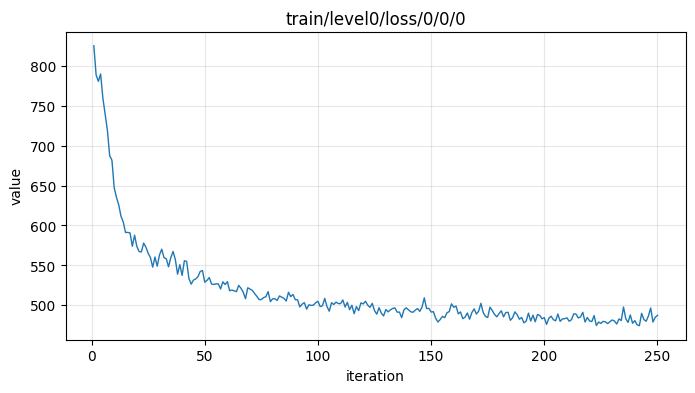

In [52]:
plot_scalar("train/level0/loss/0/0/0")

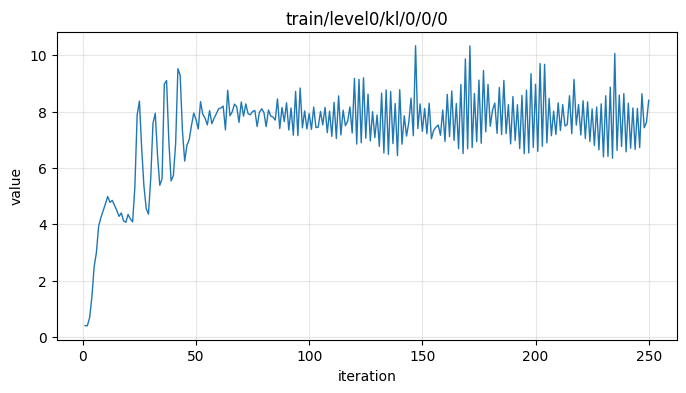

In [53]:
plot_scalar("train/level0/kl/0/0/0")

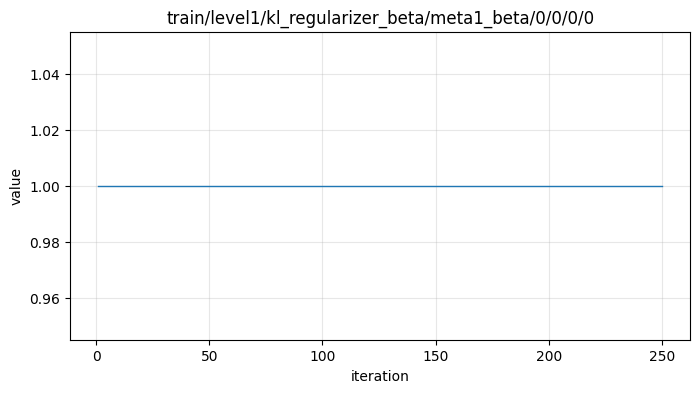

In [54]:
plot_scalar("train/level1/kl_regularizer_beta/meta1_beta/0/0/0/0")

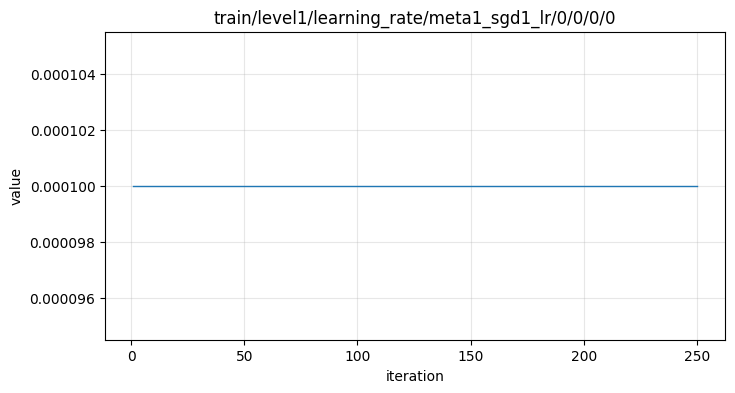

In [55]:
plot_scalar("train/level1/learning_rate/meta1_sgd1_lr/0/0/0/0")

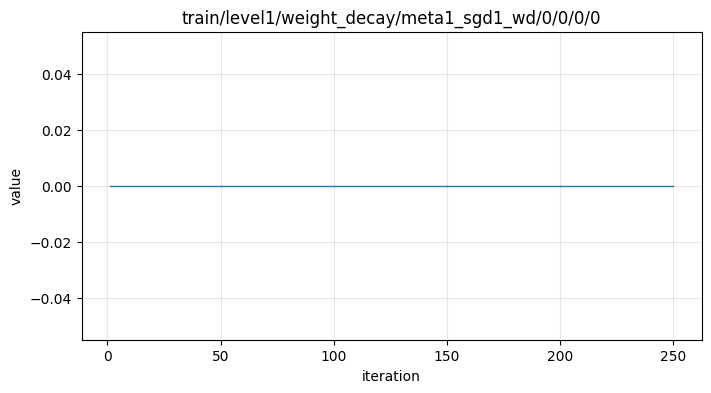

In [56]:
plot_scalar("train/level1/weight_decay/meta1_sgd1_wd/0/0/0/0")

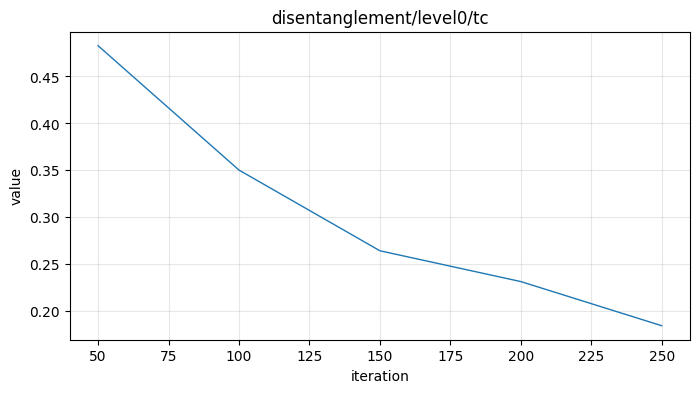

In [57]:
plot_scalar("disentanglement/level0/tc")

## Plot all scalars in a grid

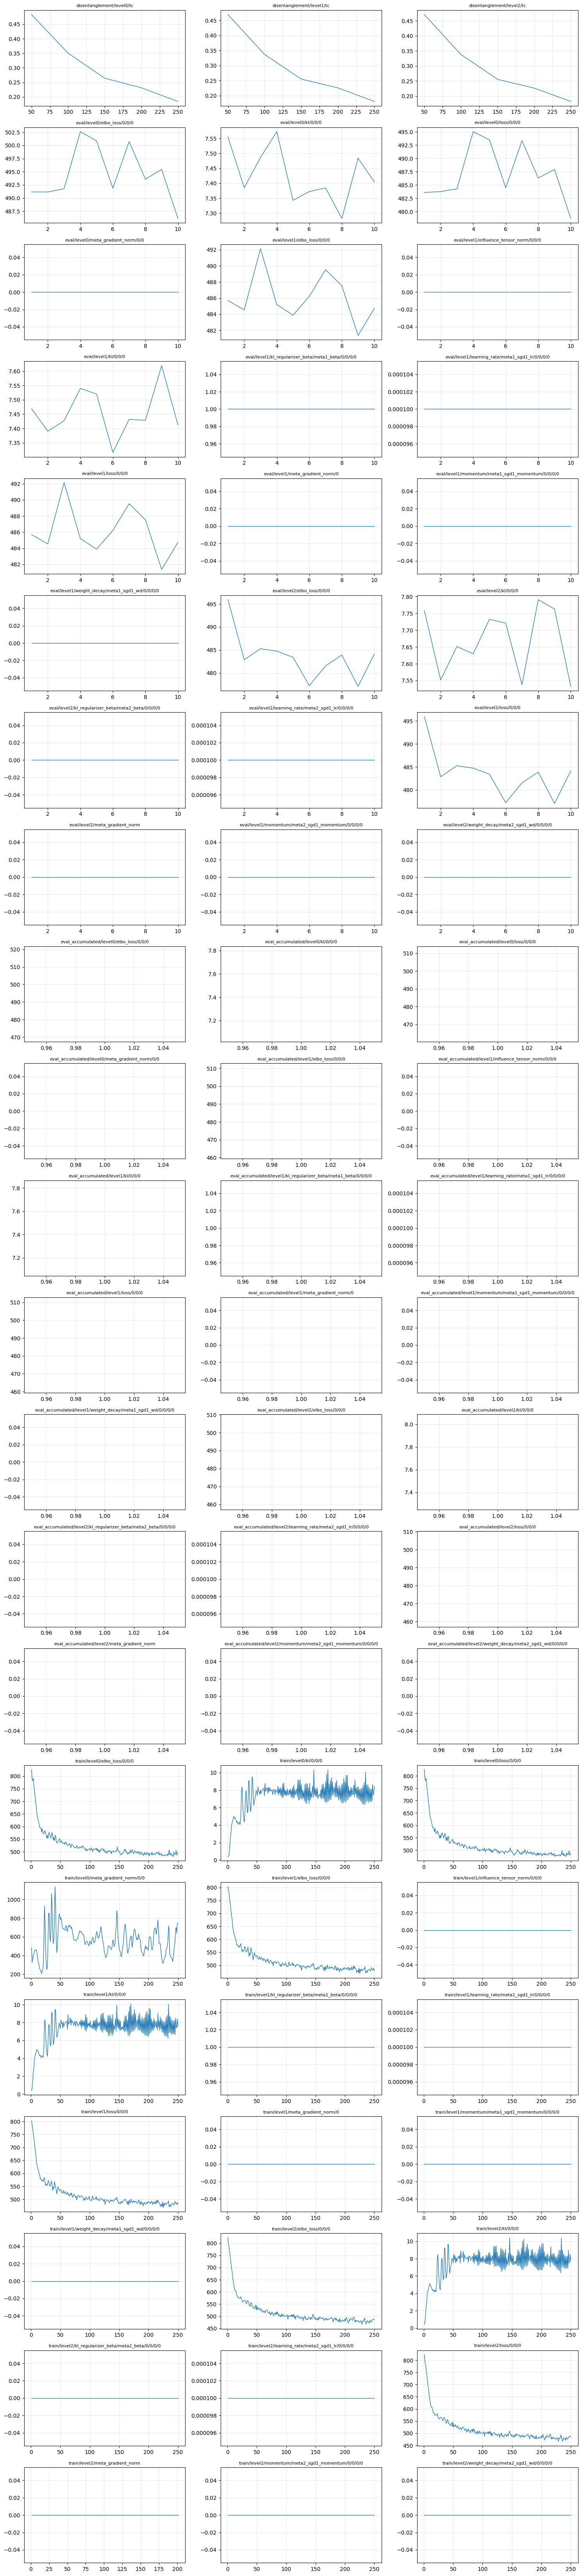

In [58]:
with h5py.File(h5_path, "r") as f:
    titles = []
    def visit(name, obj):
        if isinstance(obj, h5py.Dataset) and not name.endswith("_iterations"):
            titles.append(name)
    f.visititems(visit)
    titles.sort()
    series = {}
    for t in titles:
        iters = f[f"{t}_iterations"][:]
        vals = f[t][:]
        mask = (iters >= 0) & ~np.isnan(vals)
        series[t] = (iters[mask], vals[mask])

ncols = 3
nrows = (len(series) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
for ax, (title, (its, vs)) in zip(axes, series.items()):
    ax.plot(its, vs, linewidth=1)
    ax.set_title(title, fontsize=8); ax.grid(True, alpha=0.3)
for ax in axes[len(series):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Image gallery
Shows every PNG saved by the HDF5 logger's internal MatplotlibLogger.

90 images found

=== vae_grid_level0_prediction_0_0_0_0_101.png ===


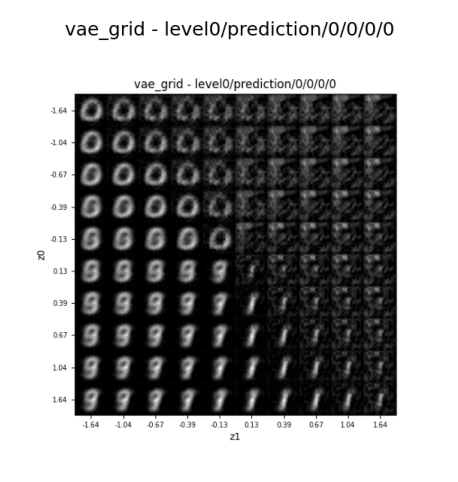


=== vae_grid_level0_prediction_0_0_0_0_151.png ===


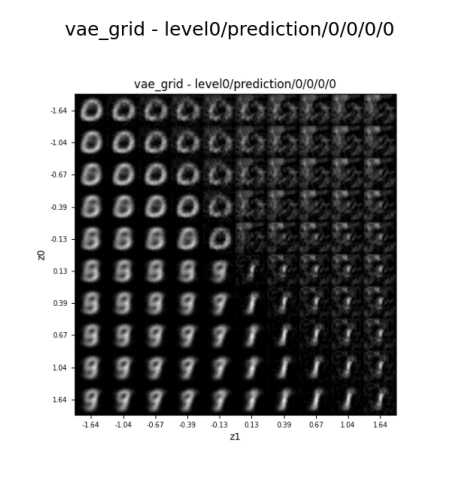


=== vae_grid_level0_prediction_0_0_0_0_201.png ===


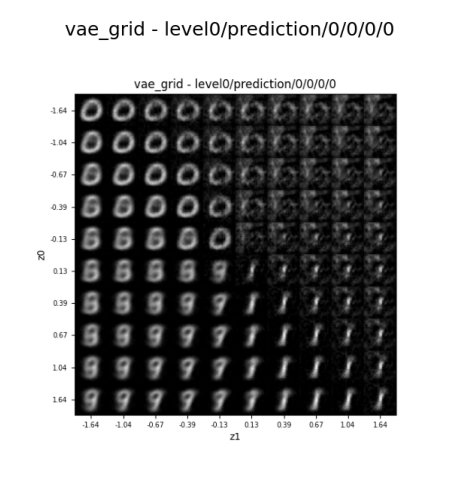


=== vae_grid_level0_prediction_0_0_0_0_251.png ===


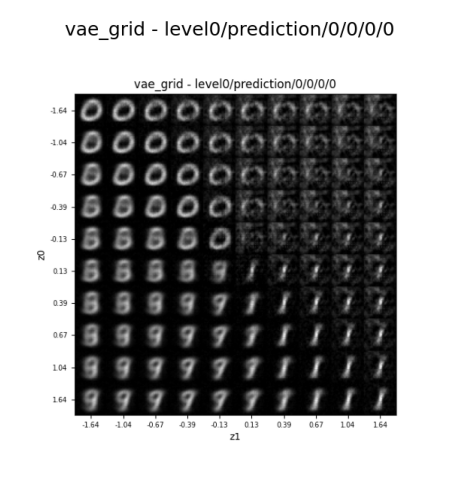


=== vae_grid_level0_prediction_0_0_0_0_51.png ===


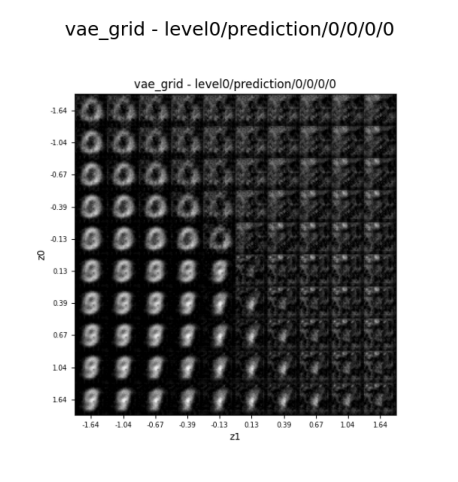


=== vae_grid_level1_prediction_0_0_0_0_101.png ===


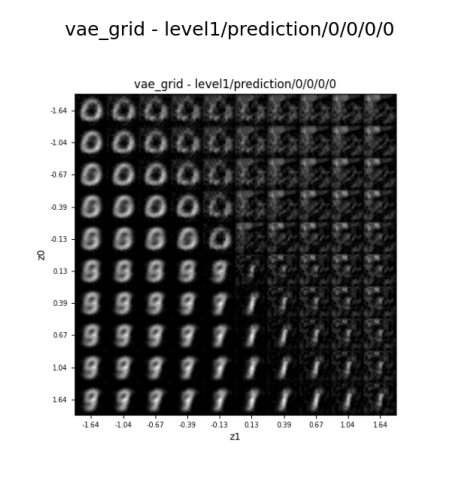


=== vae_grid_level1_prediction_0_0_0_0_151.png ===


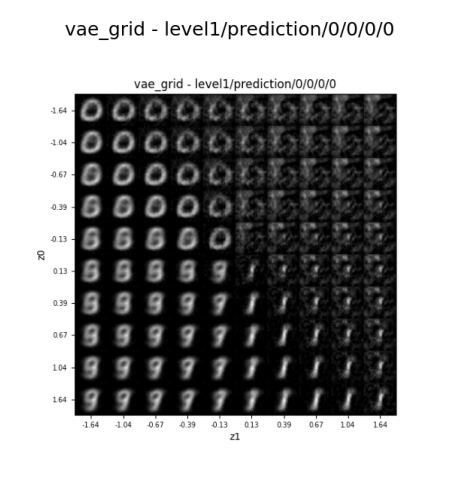


=== vae_grid_level1_prediction_0_0_0_0_201.png ===


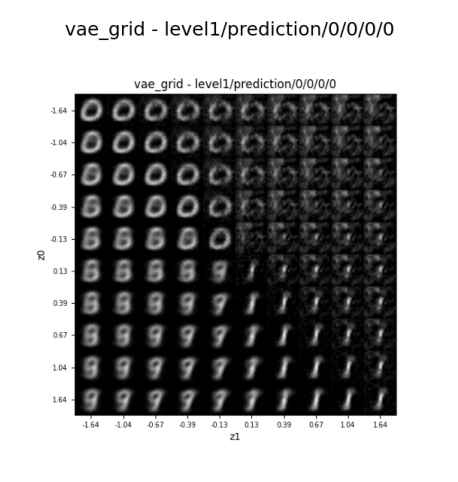


=== vae_grid_level1_prediction_0_0_0_0_251.png ===


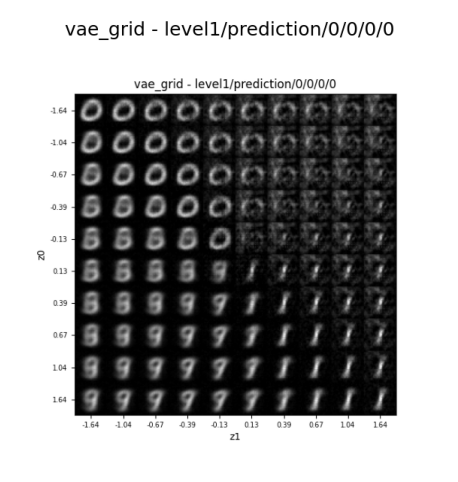


=== vae_grid_level1_prediction_0_0_0_0_51.png ===


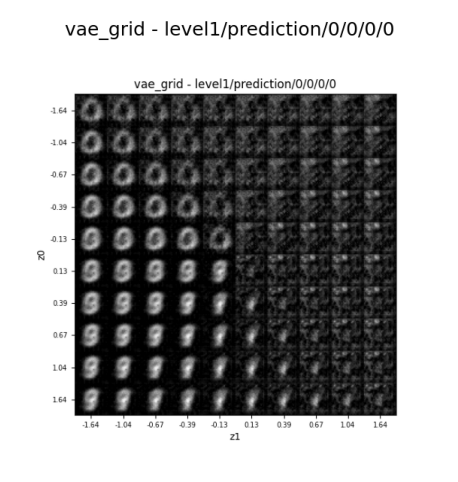


=== vae_grid_level2_prediction_0_0_0_0_101.png ===


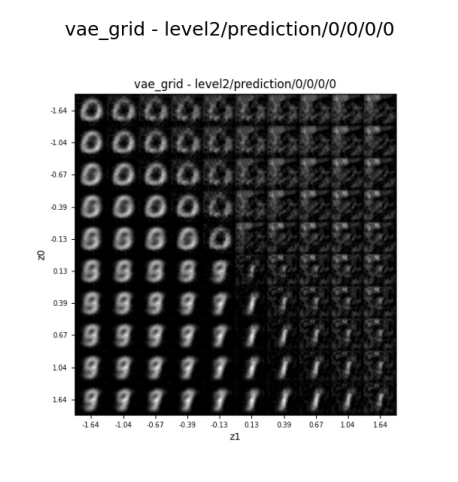


=== vae_grid_level2_prediction_0_0_0_0_151.png ===


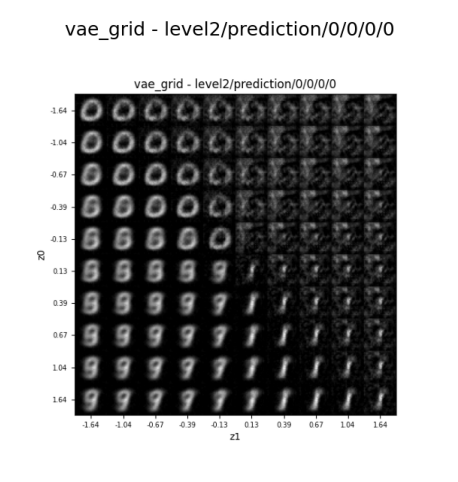


=== vae_grid_level2_prediction_0_0_0_0_201.png ===


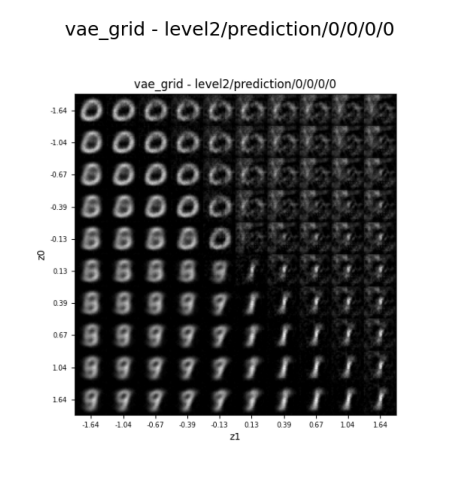


=== vae_grid_level2_prediction_0_0_0_0_251.png ===


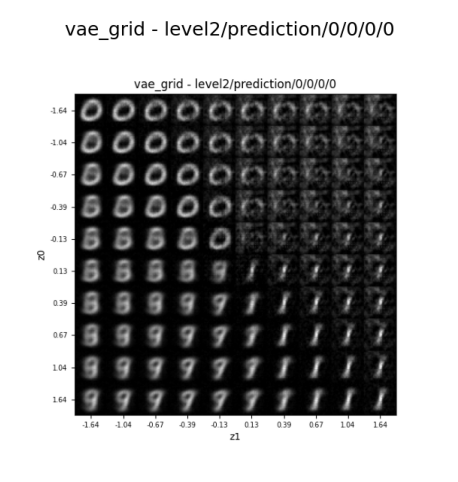


=== vae_grid_level2_prediction_0_0_0_0_51.png ===


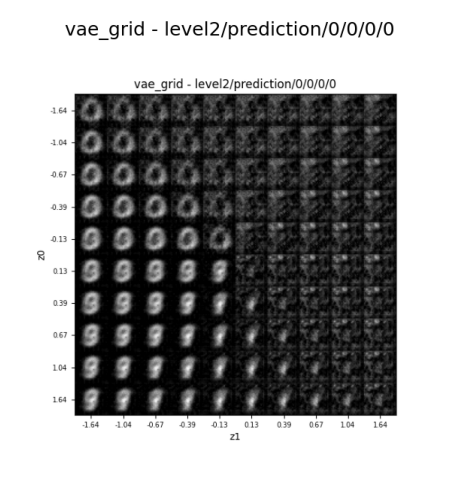


=== vae_interp_level0_prediction_0_0_0_0_0_101.png ===


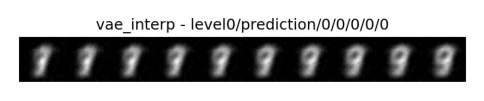


=== vae_interp_level0_prediction_0_0_0_0_0_151.png ===


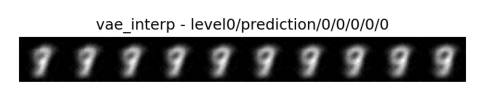


=== vae_interp_level0_prediction_0_0_0_0_0_201.png ===


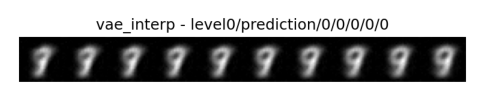


=== vae_interp_level0_prediction_0_0_0_0_0_251.png ===


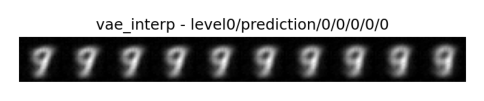


=== vae_interp_level0_prediction_0_0_0_0_0_51.png ===


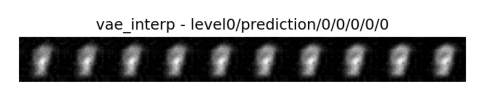

In [59]:
images = sorted(img_dir.rglob("*.png")) if img_dir.exists() else []
print(f"{len(images)} images found")
for p in images[:20]:
    print(f"\n=== {p.relative_to(img_dir)} ===")
    plt.figure(figsize=(6, 6))
    plt.imshow(np.asarray(Image.open(p)))
    plt.axis("off"); plt.show()